# Lezione 6: NumPy and Pandas

### Contatti
[matteo.caldana@polimi.it](mailto:matteo.caldana@polimi.it).

### Un veloce throwback al terminale

Anche in Colab abbiamo il terminale, se volessimo potremmo fare tutto dal esso (ma è molto scomodo vedere il contenuto dei files senza un editor di testo).

## NumPy

NumPy è una libreria di algebra lineare che contiene tutte le funzionalità di Matlab (esclusi i widget aggiuntivi). Visto che nei corsi di numerica vi spiegano già Matlab nei dettagli, questa è solo una carrellata delle peculiarità di Numpy. Se siete interessati a sapere come convertire comandi Matlab in NumPy trovate qui una comoda guida:

https://numpy.org/doc/stable/user/numpy-for-matlab-users.html

Oppure leggete la guida completa

https://numpy.org/doc/stable/user/basics.html

In [1]:
import numpy as np

### Creare Array

Creiamo un elemento di $R$, un array 0D

In [2]:
a0d = np.array(0.32)
a0d

array(0.32)

Creiamo un elmento di $R^{m_1}$, un array 1D

In [3]:
a1d = np.array([0.1, 0.2, 0.3])
a1d

array([0.1, 0.2, 0.3])

Creiamo un elemento di $R^{{m_1}\times{m_2}}$, un array 2D

In [4]:
a2d = np.array([[0.1, 0.2, 0.3], [-0.4, -0.5, 0.6]])
a2d

array([[ 0.1,  0.2,  0.3],
       [-0.4, -0.5,  0.6]])

Possiamo creare un qualsiare elemento di $R^{{m_1}\times{m_2}\times ... \times{m_n}}$, un array $n$-D.

Ci sono le stesse funzioni per crearli di Matlab
- `zeros`
- `ones`
- `eye`
- `linspace`
- `diag`

Ed alcune nuove come `empty` per avere della memoria non-inizializzata (più veloce, l'OS non deve fare pulizia)

In [5]:
a3d = np.empty((2, 3, 4))
a3d

array([[[-0.25, -0.5 ,  0.  , -0.25],
        [ 0.25, -0.5 ,  0.5 , -0.25],
        [ 0.25,  0.  ,  0.5 ,  0.25]],

       [[ 0.25,  0.5 ,  0.  ,  0.25],
        [-0.25,  0.5 , -0.5 ,  0.25],
        [-0.25,  0.  , -0.5 , -0.25]]])

Come controllare le dimensioni di un array?

In [6]:
print("Quali sono m_1, ..., m_n?: ", a3d.shape)
print("Che dimensione ha?: ", a3d.ndim)
print("Quanti elementi in totale?", a3d.size, "(prodotto di m_1 * ... * m_n)")

Quali sono m_1, ..., m_n?:  (2, 3, 4)
Che dimensione ha?:  3
Quanti elementi in totale? 24 (prodotto di m_1 * ... * m_n)


Numpy è veloce poichè implementato in C, per questo motivo gli elementi degli array, come in C, hanno un tipo e un numero di bit che viene utilizzato per questo tipo

In [7]:
a2d.dtype

dtype('float64')

Il tipo può essere imposto durante la creazione (con un kwarg) o cambiato a posteriori (cast)

In [8]:
b = np.array([1, 2, 3], dtype=np.float32)
print(b)
b = np.array([1, 2, 3], dtype=np.int64)
print(b)

a1d.astype(np.int32) #procedimento di a=1.0 a=int(a)

[1. 2. 3.]
[1 2 3]


array([0, 0, 0], dtype=int32)

### Operazioni per asse

La maggior parte delle operazioni matematiche, es. `np.sum`, possono essere applicate su tutto l'array o su un sotto insieme di assi.

In [9]:
a2d

array([[ 0.1,  0.2,  0.3],
       [-0.4, -0.5,  0.6]])

Somma totale

In [10]:
np.sum(a2d)

np.float64(0.30000000000000004)

Somma colonna per colonna (la sommatoria è effettuata per ogni valore nel `range(shape[0])`)
$$\sum_{i}^{m_1} a_{ij}$$

In [11]:
np.sum(a2d, axis=0)

array([-0.3, -0.3,  0.9])

Somma riga per riga (la sommatoria è effettuata per ogni valore nel `range(shape[1])`)
$$\sum_{j}^{m_2} a_{ij}$$

In [12]:
np.sum(a2d, axis=1)

array([ 0.6, -0.3])

Possiamo passare ad `axis` uno o più indici (tramite una tupla).

In [13]:
np.sum(a2d, axis=(0, 1))

np.float64(0.30000000000000004)

### Copy and View

Per poter cambiare un elemento di un array, tipo

In [14]:
b[1] = 99
b

array([ 1, 99,  3])

L'oggetto `b[1]` non può essere una copia di `b`, deve poter accedere alla memoria di `b` per cambiarlo!

Esistono due tipi di array:
- `copy`: possiedono la memoria a cui stanno facendo riferimento (es. `b`)
- `view`: **non** possiedono la memoria a cui stanno facendo riferimento (es. `b[1]`)

Come controllare?

In [15]:
c = b[1:2]
print("`b`          è una copia?", b.base is None)
print("`c = b[1:2]` è una copia?", c.base is None)

`b`          è una copia? True
`c = b[1:2]` è una copia? False


### Reshape

Uno dei motivi che rende NumPy così veloce è che dato un array, tutti i suoi elementi sono **contigui in memoria**, questo significa che NumPy garantisce che tutti gli elementi dell'array, dal primo all'ultimo, sono ordinati e fisicamente vicini sul PC.

Per **fisicamente vicini** intendo letteralmente che sono salvati in transistor che sono vicini tra di loro nella RAM in termini di nanometri. Questa proprietà è ereditata direttamente dal fatto che gli array di C
```c
void buffer[] = ...
```
hanno questa caratteristica. Indipendetenmente dalla dimensione `ndim`, NumPy salva sempre i dati in un singolo array di C.

Questo significa che **i seguenti** due array hanno la stessa rapprentazione in memoria anche se hanno dimensione diversa

In [16]:
a1d = np.array([1, 2, 3, 4, 5, 6])
a2d = np.array([[1, 2, 3], [4, 5, 6]])

print(a1d)
print(a2d)

[1 2 3 4 5 6]
[[1 2 3]
 [4 5 6]]


Capita quindi spesso che sia utile passare da una rappresentazione all'altra senza fare una `copy` ma usando invece una `view`.

Ecco l'importanza del comando `reshape`

In [17]:
a2d_view = a1d.reshape((2, 3))
print(a2d_view)
print(a2d_view.base is None)

[[1 2 3]
 [4 5 6]]
False


Naturalmente, `reshape` funziona solo se e solo se il prodotto dei termini della tupla passata è pari alla `size` dell'array da cui stiamo chiamando il metodo `reshape`.

#### Memory layout: "row major" detto anche "right layout"

<img src="https://github.com/AIM-mate/corso-python-26/blob/master/lezione-6/assets/row-major.png?raw=1" alt="row-major" style="width: 300px;"/>

Il modo in cui `reshape` "spiattella" (da 2D a 1D) o "avvolge" (da 1D a 2D) la memoria è abbastanza intuitivo
- la "spiattella" leggendo la matrice prima da sinitra verson destra e poi dall'alto al basso (come si legge una pagina di un libro).
- la "avvolge" esattamente al contrario, spezzando in una nuova righa ogni volta che raggiunge il numero di caratteri pari al numero di colonne della matrice

Questa convenzione di chiama "row major" perchè le righe `a2d[i, :]` rimangono intatte per ogni `i`.

Questo funziona per 1D e 2D, ma cosa succede per array a più alta dimensione?

Il ragionamento è ricorsivo: per esempio per un array 3D `a3d[:, :, :]`, lo si divide in matrici `a3d[j, :, :]` e si "spiattella" ogni matrice e poi si uniscono insieme le matrici spiattellate.

Questa convenzione di chiama "right layout" perchè l'asse più a destra `a3d[j, i, :]` rimane intatto per ogni `i` e `j`.

### Indexing

L'indexing funziona esattamente come per le liste, e similmente a Matlab

In [18]:
# elemento sulla seconda riga e terza colonna
print(a2d[1, 2])
# tutte gli elmenti della prima riga in posizione pari: primo (0), terzo (2)
print(a2d[0, ::2])

6
[1 3]


Si possono passare liste/array come indici, ricordatevi che anche i **numeri negativi valgono**.

Se l'array ha dimensione $n>1$ tutte le liste/array che vengono passate devono avere la stessa lunghezza o seguire delle regole molto particolare, vedete https://numpy.org/doc/stable/user/basics.indexing.html.

In [19]:
idxs = np.array([-1, -3])
a1d[idxs]

array([6, 4])

Caso 2D, gli indici vengono trattati come tuple di indexing

In [20]:
idxs_rows = np.array([1, 1])
idxs_cols = np.array([1, 2])
# estraiamo l=2 elementi (dove l==idxs_rows.size==idxs_cols.size)
# alle posizioni (1, 1) e (1, 2)
a2d[idxs_rows, idxs_cols]

array([5, 6])

Un altro modo per estrarre elementi è con una **maschera booleana**, cioè un array della stessa esatta *shape* dell'array che indica su quali elementi stiamo lavorando

In [21]:
a = np.arange(56).reshape((7, 8))
a

array([[ 0,  1,  2,  3,  4,  5,  6,  7],
       [ 8,  9, 10, 11, 12, 13, 14, 15],
       [16, 17, 18, 19, 20, 21, 22, 23],
       [24, 25, 26, 27, 28, 29, 30, 31],
       [32, 33, 34, 35, 36, 37, 38, 39],
       [40, 41, 42, 43, 44, 45, 46, 47],
       [48, 49, 50, 51, 52, 53, 54, 55]])

In [22]:
boolean_mask = a > 31
print("boolean mask:\n", boolean_mask)
a[a>31] += 100
a

boolean mask:
 [[False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]
 [ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True]]


array([[  0,   1,   2,   3,   4,   5,   6,   7],
       [  8,   9,  10,  11,  12,  13,  14,  15],
       [ 16,  17,  18,  19,  20,  21,  22,  23],
       [ 24,  25,  26,  27,  28,  29,  30,  31],
       [132, 133, 134, 135, 136, 137, 138, 139],
       [140, 141, 142, 143, 144, 145, 146, 147],
       [148, 149, 150, 151, 152, 153, 154, 155]])

`np.where` è una funzione che potenzia le maschere booleane

In [23]:
# se passiamo un solo valore, la maschera booleana
# troviamo gli indici dove la maschera booleana è vera
print(np.where(a>31))

# se passiamo tre valori:
# - la maschera booleana
# - valore caso VERO
# - valore caso FALSO
# applichiamo un IF-ELSE con la maschera booleana
print(np.where(a>31, -1, 7))

(array([4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6,
       6, 6]), array([0, 1, 2, 3, 4, 5, 6, 7, 0, 1, 2, 3, 4, 5, 6, 7, 0, 1, 2, 3, 4, 5,
       6, 7]))
[[ 7  7  7  7  7  7  7  7]
 [ 7  7  7  7  7  7  7  7]
 [ 7  7  7  7  7  7  7  7]
 [ 7  7  7  7  7  7  7  7]
 [-1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1 -1 -1]]


#### Problemi non solo da Matematici

A differenza di Matlab dove tutto è una matrice (e quindi un vettore è una matrice con una riga), in NumPy siamo più vicini a quello che succede in matematica, in particolare, un elemento di
- $R^n$
- $R^{1 \times n}$
- $R^{n \times 1}$

Sono tre cose ben diverse

In [24]:
a1d = np.array([1, 2, 3])
a2d_col = a1d.reshape((3, 1))
a2d_row = a1d.reshape((1, 3))
print("1D vector")
print(a1d)
print("2D column matrix")
print(a2d_col)
print("2D row matrix")
print(a2d_row)

1D vector
[1 2 3]
2D column matrix
[[1]
 [2]
 [3]]
2D row matrix
[[1 2 3]]


### Broadcasting

NumPy è veloce solo fino a quando riusciamo ad evitare **for** loops.

I **for** loops vanno evitati come la peste.

Sarete tanto più bravi come programmatori NumPy, tanto più riuscirete a evitare di scrivere **for**.

Il **broadcasting** dice che possiamo applicare un operazione a due array che non hanno la stessa shape se

aggiungendo dimensione 1 all'array con il minor `ndims` a sinistra fino ad averne come quello con dimensione maggiore, si hanno dimensioni corrispontenti uguali o una delle due è 1.

#### Esempio 1

<img src="https://github.com/AIM-mate/corso-python-26/blob/master/lezione-6/assets/broadcasting_1.png?raw=1" alt="b1" style="width: 400px;"/>


In [27]:
# a.shape =       (3,)
# b.shape = () -> (1,)

a = np.array([1.0, 2.0, 3.0])
b = 2.0
a + b

array([3., 4., 5.])

#### Esempio 2: aggiungere una traslazione a una lista di punti in 3D

<img src="https://github.com/AIM-mate/corso-python-26/blob/master/lezione-6/assets/broadcasting_2.png?raw=1" alt="b2" style="width: 500px;"/>

In [30]:
a = np.array([[ 0.0,  0.0,  0.0],
              [10.0, 10.0, 10.0],
              [20.0, 20.0, 20.0],
              [30.0, 30.0, 30.0]])
b = np.array([1.0, 2.0, 3.0])

# a.shape =         (4, 3)
# b.shape = (3,) -> (1, 3)

print (a + b)

b = np.array([1.0, 2.0, 3.0, 4.0])
# a.shape =         (4, 3)
# b.shape = (4,) -> (1, 4)
# NON compatibili!

# a.shape =         (4, 3)
# b.shape = (4,) -> (4, 1)
# Compatibili! con reshape

[[ 1.  2.  3.]
 [11. 12. 13.]
 [21. 22. 23.]
 [31. 32. 33.]]


#### Esempio 3
<img src="https://github.com/AIM-mate/corso-python-26/blob/master/lezione-6/assets/broadcasting_3.png?raw=1" alt="b3" style="width: 500px;"/>

In [33]:
a = np.array([0.0, 10.0, 20.0, 30.0])
b = np.array([1.0, 2.0, 3.0])

# a[:, np.newaxis] == a.reshape((4, 1))
# è utile perchè funziona per qualunque dimensione di `a`
# mentre con il reshape se la dimensione != 4 abbiamo errore

# a.shape =         (4, 1)
# b.shape = (3,) -> (1, 3)

a[:, np.newaxis] * b

array([[ 0.,  0.,  0.],
       [10., 20., 30.],
       [20., 40., 60.],
       [30., 60., 90.]])

## Pandas

In data, c'è un esempio dei files che potremmo aver ottenuto lo scorso laboratorio grazie a Gemini.

Iniziamo a trovare quali sono tutti i CSV nella cartella.

In [51]:
import os

if not os.path.exists("data"):
  !git clone https://github.com/AIM-mate/corso-python-26.git
  !cp -R corso-python-26/lezione-6/data .
  # le righe che cominciano con ! è un bash

In [35]:
files = [file for file in os.listdir("data") if file.endswith("csv")]
files

['meteo_Torino_2025_Agosto.csv',
 'meteo_Napoli_2025_Dicembre.csv',
 'meteo_Roma_2025_Dicembre.csv',
 'meteo_Roma_2025_Novembre.csv',
 'meteo_Firenze_2025_Dicembre.csv',
 'meteo_Trento_2025_Settembre.csv',
 'meteo_Milano_2025_Agosto.csv',
 'meteo_Trento_2025_Ottobre.csv',
 'meteo_Napoli_2025_Settembre.csv',
 'meteo_Milano_2025_Settembre.csv',
 'meteo_Trento_2025_Agosto.csv',
 'meteo_Roma_2025_Agosto.csv',
 'meteo_Firenze_2025_Settembre.csv',
 'meteo_Napoli_2025_Agosto.csv',
 'meteo_Firenze_2025_Novembre.csv',
 'meteo_Roma_2025_Ottobre.csv',
 'meteo_Torino_2025_Ottobre.csv',
 'meteo_Palermo_2025_Novembre.csv',
 'meteo_Firenze_2025_Agosto.csv',
 'meteo_Firenze_2025_Ottobre.csv',
 'meteo_Milano_2025_Dicembre.csv',
 'meteo_Palermo_2025_Settembre.csv',
 'meteo_Torino_2025_Novembre.csv',
 'meteo_Torino_2025_Dicembre.csv',
 'meteo_Trento_2025_Novembre.csv',
 'meteo_Trento_2025_Dicembre.csv',
 'meteo_Milano_2025_Novembre.csv',
 'meteo_Torino_2025_Settembre.csv',
 'meteo_Napoli_2025_Ottobre.csv

Carichiamo tutti i files con Pandas

In [52]:
import pandas as pd

dfs = [pd.read_csv(f"./data/{file}") for file in files]
dfs[0]

,city,year,month,Giorno G,T Media,T min,T max,Precip.,Umidità UR%,Vento Max,Raffica,Fenomeni,Info
0,Torino,2025,Agosto,1,23 °C,19 °C,27 °C,1 mm,61 %,-,4 km/h,Nessuno,>
1,Torino,2025,Agosto,2,22 °C,18 °C,26 °C,0 mm,70 %,-,4 km/h,NaN,>
2,Torino,2025,Agosto,3,23 °C,17 °C,28 °C,n/d,51 %,-,6 km/h,NaN,>
3,Torino,2025,Agosto,4,23 °C,16 °C,29 °C,-,52 %,-,4 km/h,Nessuno,>
4,Torino,2025,Agosto,5,24 °C,18 °C,30 °C,-,59 %,-,3 km/h,Nessuno,>
5,Torino,2025,Agosto,6,24 °C,19 °C,28 °C,0 mm,63 %,-,5 km/h,Nessuno,>
6,Torino,2025,Agosto,7,25 °C,22 °C,29 °C,1 mm,61 %,-,3 km/h,Nessuno,>
7,Torino,2025,Agosto,8,26 °C,19 °C,32 °C,-,61 %,-,3 km/h,Nessuno,>
8,Torino,2025,Agosto,9,28 °C,21 °C,34 °C,-,61 %,-,4 km/h,Nessuno,>
9,Torino,2025,Agosto,10,29 °C,22 °C,36 °C,-,51 %,-,4 km/h,Nessuno,>


Concateniamo tutti i DataFrame (i files), in un DataFrame unico

In [53]:
df = pd.concat(dfs)

Controllare le categorie di valori in una colonna

In [54]:
df["city"].unique()

array(['Torino', 'Napoli', 'Roma', 'Firenze', 'Trento', 'Milano',
       'Palermo'], dtype=object)

L'**indice** di un DataFrame è una serie di etichette che identificano ciascuna riga. Le etichette possono essere numeri interi, stringhe o qualsiasi altro tipo **hashable**. L'indice viene utilizzato per l'accesso e l'allineamento basati sulle etichette e può essere consultato o modificato tramite questo attributo.

In [55]:
df.index

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9,
       ...
       20, 21, 22, 23, 24, 25, 26, 27, 28, 29],
      dtype='int64', length=1071)

In [56]:
df.index.unique()

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30],
      dtype='int64')

Si accede all'indice con `loc[]`, le parentesi `[]` sono riservate per le colonne

In [57]:
df.loc[0]

,city,year,month,Giorno G,T Media,T min,T max,Precip.,Umidità UR%,Vento Max,Raffica,Fenomeni,Info
0,Torino,2025,Agosto,1,23 °C,19 °C,27 °C,1 mm,61 %,-,4 km/h,Nessuno,>
0,Napoli,2025,Dicembre,1,11 °C,4 °C,17 °C,2 mm,75 %,-,2 km/h,Nessuno,>
0,Roma,2025,Dicembre,1,10 °C,5 °C,15 °C,4 mm,76 %,-,5 km/h,NaN,>
0,Roma,2025,Novembre,1,18 °C,13 °C,24 °C,0 mm,84 %,-,3 km/h,Nessuno,>
0,Firenze,2025,Dicembre,1,9 °C,6 °C,12 °C,10 mm,92 %,-,2 km/h,NaN,>
0,Trento,2025,Settembre,1,21 °C,16 °C,24 °C,8 mm,73 %,-,9 km/h,NaN,>
0,Milano,2025,Agosto,1,24 °C,19 °C,28 °C,3 mm,65 %,22 km/h,6 km/h,NaN,>
0,Trento,2025,Ottobre,1,15 °C,8 °C,20 °C,0 mm,48 %,22 km/h,4 km/h,Nessuno,>
0,Napoli,2025,Settembre,1,24 °C,18 °C,28 °C,-,59 %,-,4 km/h,Nessuno,>
0,Milano,2025,Settembre,1,20 °C,17 °C,23 °C,3 mm,81 %,-,4 km/h,NaN,>


A meno che abbiamo un indice particolarmente significativo, spesso si cerca di mantenere l'indice "pulito", resettandolo al `range(0, len(df))`

In [58]:
df = df.reset_index(drop=True)
df.index

RangeIndex(start=0, stop=1071, step=1)

Controlliamo i tipi delle colonne

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1071 entries, 0 to 1070
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   city         1071 non-null   object
 1   year         1071 non-null   int64 
 2   month        1071 non-null   object
 3   Giorno G     1071 non-null   int64 
 4   T Media      1071 non-null   object
 5   T min        1071 non-null   object
 6   T max        1071 non-null   object
 7   Precip.      1071 non-null   object
 8   Umidità UR%  1071 non-null   object
 9   Vento Max    1071 non-null   object
 10  Raffica      1071 non-null   object
 11  Fenomeni     658 non-null    object
 12  Info         1071 non-null   object
dtypes: int64(2), object(11)
memory usage: 108.9+ KB


Alcune colonne sono `object` (stringhe) quando in realtà vorremmo fossero numeri (es. la temperatura che ha il simbolo di grado centigrado).

Per sistemare queste colonne dobbiamo applicare una funzione per trasformare la stringa in `float`.

In [60]:
def parse(string):
    # Perche' vale la pena usare try/except qui?
    # controllare se una stringa puo' essere trasformata
    # in float e' estremamente costoso e complesso
    # Notate inoltre come la parte di codice nel try sia la piu'
    # piccola possibile e catturiamo solo ValueError
    first_part = string.split(" ")[0]
    try:
        return float(first_part)
    except ValueError:
        return float('nan')

for col in ["T Media", "T min", "T max", "Umidità UR%", "Vento Max", "Precip.", "Raffica"]:
  df[col] = df[col].apply(parse)

df

,city,year,month,Giorno G,T Media,T min,T max,Precip.,Umidità UR%,Vento Max,Raffica,Fenomeni,Info
0,Torino,2025,Agosto,1,23.0,19.0,27.0,1.0,61.0,NaN,4.0,Nessuno,>
1,Torino,2025,Agosto,2,22.0,18.0,26.0,0.0,70.0,NaN,4.0,NaN,>
2,Torino,2025,Agosto,3,23.0,17.0,28.0,NaN,51.0,NaN,6.0,NaN,>
3,Torino,2025,Agosto,4,23.0,16.0,29.0,NaN,52.0,NaN,4.0,Nessuno,>
4,Torino,2025,Agosto,5,24.0,18.0,30.0,NaN,59.0,NaN,3.0,Nessuno,>
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1066,Napoli,2025,Novembre,26,11.0,9.0,14.0,10.0,87.0,NaN,5.0,NaN,>
1067,Napoli,2025,Novembre,27,10.0,7.0,13.0,1.0,75.0,NaN,6.0,NaN,>
1068,Napoli,2025,Novembre,28,10.0,7.0,14.0,0.0,65.0,NaN,5.0,Nessuno,>
1069,Napoli,2025,Novembre,29,10.0,6.0,14.0,NaN,71.0,NaN,3.0,Nessuno,>


In [61]:
df.describe()

,year,Giorno G,T Media,T min,T max,Precip.,Umidità UR%,Vento Max,Raffica
count,1071.0,1071.000000,1071.000000,1071.000000,1071.000000,665.000000,1071.000000,102.000000,1071.000000
mean,2025.0,15.803922,16.554622,11.944911,21.225957,3.482707,71.769374,22.500000,4.887021
std,0.0,8.839632,7.393389,7.253858,7.648427,6.256810,12.444345,10.593992,2.551402
min,2025.0,1.000000,-1.000000,-6.000000,3.000000,0.000000,31.000000,4.000000,1.000000
25%,2025.0,8.000000,11.000000,6.000000,15.000000,0.000000,64.000000,13.500000,3.000000
50%,2025.0,16.000000,17.000000,12.000000,21.000000,1.000000,72.000000,24.000000,4.000000
75%,2025.0,23.000000,23.000000,18.000000,28.000000,4.000000,80.000000,28.000000,6.000000
max,2025.0,31.000000,32.000000,27.000000,40.000000,48.000000,100.000000,57.000000,15.000000


Creiamo la data

In [62]:
MONTH_TABLE = {
    "Agosto": 8,
    "Settembre": 9,
    "Ottobre": 10,
    "Novembre": 11,
    "Dicembre": 12
}

def create_date(row):
  return f"{row['year']:d}-{MONTH_TABLE[row['month']]:02}-{row['Giorno G']:02}"

df["data"] = df.apply(create_date, axis=1)
df["data"] = pd.to_datetime(df['data'])

df["data"]

,data
0,2025-08-01
1,2025-08-02
2,2025-08-03
3,2025-08-04
4,2025-08-05
...,...
1066,2025-11-26
1067,2025-11-27
1068,2025-11-28
1069,2025-11-29


### Temperatura media a Milano

In [65]:
# I dati di Milano
df_milano = df[df["city"] == "Milano"]

# Calcoliamo la media
df_milano["T Media"].mean()

np.float64(14.607843137254902)

#### Precipitazioni a Milano il 25 Dicembre 2025

In [66]:
row = df[(df["city"] == "Milano") & (df["data"] == "2025-12-25")]
row["Precip."]

,Precip.
637,6.0


#### Confronta la temperatura media di tutte le città

In [67]:
df.groupby('city')['T Media'].mean()

,T Media
city,
Firenze,16.516340
Milano,14.607843
Napoli,18.490196
Palermo,20.810458
Roma,17.810458
Torino,14.418301
Trento,13.228758


#### Confronta la temperatura minima e massima di tutte le città

In [68]:
# mappiamo una colonna a un'operazione
df.groupby('city').agg({"T min": "min", "T max": "max"})
#"min" e "max" sono funzioni

,T min,T max
city,,
Firenze,-4.0,40.0
Milano,-2.0,36.0
Napoli,2.0,37.0
Palermo,8.0,34.0
Roma,1.0,37.0
Torino,-2.0,36.0
Trento,-6.0,37.0


#### Crea una tabella con le città sulle colonne e la temperatura media come valore per ogni data

<img src="https://github.com/AIM-mate/corso-python-26/blob/master/lezione-6/assets/reshaping_pivot.png?raw=1" alt="melt" style="width: 500px;"/>

In [69]:
df_pivot = df.pivot(index='data', columns='city', values='T Media')
df_pivot

city,Firenze,Milano,Napoli,Palermo,Roma,Torino,Trento
data,,,,,,,
2025-08-01,25.0,24.0,25.0,26.0,25.0,23.0,21.0
2025-08-02,24.0,21.0,25.0,25.0,25.0,22.0,18.0
2025-08-03,23.0,22.0,25.0,26.0,24.0,23.0,23.0
2025-08-04,24.0,23.0,25.0,25.0,24.0,23.0,22.0
2025-08-05,26.0,24.0,26.0,26.0,25.0,24.0,25.0
...,...,...,...,...,...,...,...
2025-12-27,7.0,4.0,11.0,14.0,8.0,6.0,1.0
2025-12-28,3.0,3.0,8.0,12.0,6.0,5.0,2.0
2025-12-29,2.0,3.0,9.0,12.0,7.0,5.0,1.0


<Axes: xlabel='data'>

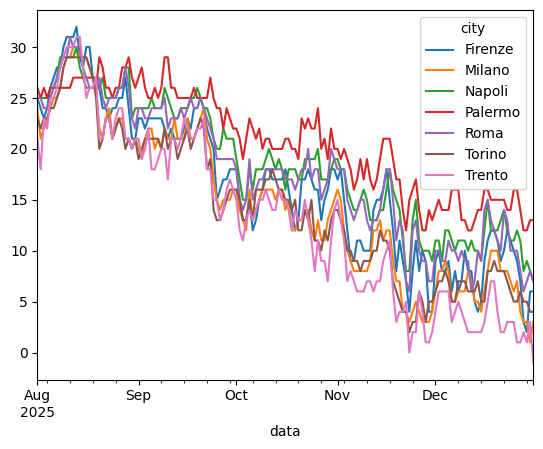

In [71]:
df_pivot.plot()

#### Da una tabella pivot torniamo indietro

<img src="https://github.com/AIM-mate/corso-python-26/blob/master/lezione-6/assets/reshaping_melt.png?raw=1" alt="melt" style="width: 500px;"/>

In [72]:
df_pivot.columns

Index(['Firenze', 'Milano', 'Napoli', 'Palermo', 'Roma', 'Torino', 'Trento'], dtype='object', name='city')

In [73]:
df_pivot.reset_index().columns

Index(['data', 'Firenze', 'Milano', 'Napoli', 'Palermo', 'Roma', 'Torino',
       'Trento'],
      dtype='object', name='city')

In [74]:
df_pivot.reset_index().melt(id_vars='data', value_name='temperature')

,data,city,temperature
0,2025-08-01,Firenze,25.0
1,2025-08-02,Firenze,24.0
2,2025-08-03,Firenze,23.0
3,2025-08-04,Firenze,24.0
4,2025-08-05,Firenze,26.0
...,...,...,...
1066,2025-12-27,Trento,1.0
1067,2025-12-28,Trento,2.0
1068,2025-12-29,Trento,1.0
1069,2025-12-30,Trento,3.0


#### Calcoliamo la media delle temperature per ogni mese e città

In [75]:
df.pivot_table(
    index='month',      # Cosa vogliamo sulle righe
    columns='city',     # Cosa vogliamo sulle colonne
    values='T Media',     # Il dato da analizzare
    aggfunc='mean',     # Come aggregare i dati (poteva essere 'sum', 'count', 'max')
).round(1) # Arrotondiamo per rendere la tabella leggibile

city,Firenze,Milano,Napoli,Palermo,Roma,Torino,Trento
month,,,,,,,
Agosto,26.4,24.7,26.5,26.5,26.4,24.5,24.6
Dicembre,8.1,6.4,10.9,14.2,9.9,6.4,3.3
Novembre,11.0,8.1,13.7,16.9,12.9,7.8,6.1
Ottobre,15.7,13.9,17.9,21.0,17.2,14.2,12.9
Settembre,21.3,19.9,23.5,25.3,22.6,19.2,19.1


#### Temperatura media a 7 giorni

In [76]:
df["temp_7day_avg"] =  df.sort_values('data').groupby('city')['T Media'].transform(lambda x: x.rolling(7).mean())

<Axes: title={'center': '7 Day Average Temp'}, xlabel='data'>

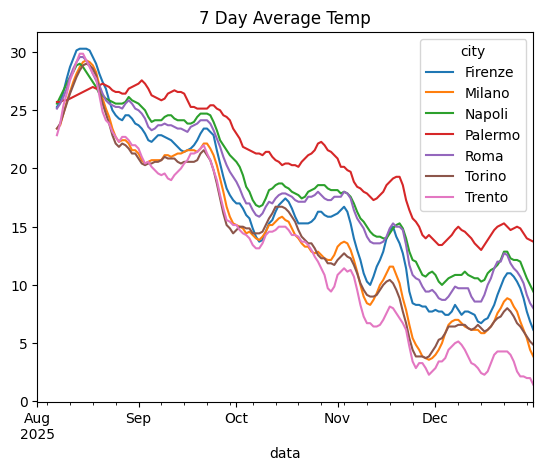

In [77]:
df.pivot(index='data', columns='city', values='temp_7day_avg').plot(title="7 Day Average Temp")